### Imports
PyTorch is standardly imported as `torch`, and its neural network module is imported as `nn`. The `numpy` library is imported for numerical operations, and `matplotlib.pyplot` is imported for plotting and visualizing data. These libraries are essential for building and training neural networks in PyTorch, as well as for handling data manipulation and visualization tasks.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

### Equations, Parameters, and Data

The equation being solved is the 1D heat equation, which describes how heat diffuses through a medium over time. The equation is given by:
```math
\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}
```
Where:
- $u(x, t)$ is the temperature distribution as a function of position $x$ and time $t$.
- $\alpha$ is the thermal diffusivity constant, which determines how quickly heat diffuses through the medium.

This equation is interesting due to the dependency of the solution on both space and time, making it a fundamental example of a parabolic partial differential equation. The ability to solve this equation using Physics-Informed Neural Networks (PINNs) allows for efficient and accurate modeling of complex systems where traditional numerical methods may struggle.

In [2]:
# ----------------------------
# 1. Parameters
# ----------------------------
alpha = 0.1                                     # Diffusion coefficient

# ----------------------------
# 2. Training Data (Initial Condition)
# u(x,0) = sin(pi x)
# ----------------------------
x_data = torch.linspace(0, 1, 20).view(-1,1)    # 20 points in space
t_data = torch.zeros_like(x_data)               # Initial time t=0
X_data = torch.cat([x_data, t_data], dim=1)     # Combine x and t for input

u_data = torch.sin(np.pi * x_data)              # Initial condition u(x,0) = sin(pi x)

# ----------------------------
# 3. Collocation Points
# ----------------------------
N_col = 1000                                    # Number of collocation points (points used to enforce PDE)
x_col = torch.rand(N_col, 1)                    # Random points in space for collocation
t_col = torch.rand(N_col, 1)                    # Random points in time for collocation
X_col = torch.cat([x_col, t_col], dim=1)        # Combine x and t for collocation points

# ----------------------------
# 4. Test Grid
# ----------------------------
x_test = torch.linspace(0,1,100)                # 100 points in space for testing   
t_test = torch.linspace(0,1,100)                # 100 points in time for testing    

X, T = torch.meshgrid(x_test, t_test, indexing='ij')            # Create a grid of (x,t) points for testing                     https://docs.pytorch.org/docs/stable/generated/torch.meshgrid.html
X_test = torch.cat([X.reshape(-1,1), T.reshape(-1,1)], dim=1)   # Reshape the grid into a list of (x,t) pairs for testing       https://docs.pytorch.org/docs/stable/generated/torch.cat.html

### Defining the Neural Network
Using an objective-oriented approach, we define a class `PINN` that inherits from `nn.Module`. This class will represent our Physics-Informed Neural Network. The constructor (`__init__`) initializes the layers of the neural network, which consist of an input layer, several hidden layers with tanh activation functions, and an output layer. The `forward` method defines how the input data flows through the network to produce the output. This structure allows us to model the solution to the heat equation as a function of both space and time, enabling us to train the network to satisfy the PDE and initial conditions.

In [ ]:
# ----------------------------
# 5. Neural Network
# ----------------------------
class PINN(nn.Module):
    def __init__(self):
        super().__init__()          # Initialize the neural network architecture. Required for all PyTorch models.
        self.net = nn.Sequential(   # Define a feedforward neural network with...
            nn.Linear(2, 32),       # 2 input features: (x,t)
            nn.Tanh(),              # Activation function: Tanh
            nn.Linear(32, 32),      # Hidden layer with 32 neurons
            nn.Tanh(),              # Activation function: Tanh
            nn.Linear(32, 1)        # 1 output feature: u(x,t)
        )

    def forward(self, x):           # Define the forward pass of the neural network. This is how the input data flows through the network to produce an output.
        return self.net(x)          # `x` is the input to the network, and `self.net(x)` computes the output by passing `x` through the defined layers.

### Training the PINN
The training process involves defining a loss function that combines the mean squared error of the initial condition and the PDE residual. The optimizer (Adam) is used to minimize this loss by updating the weights of the neural network. During each epoch, we compute the predictions of the network for both the initial condition and the collocation points, calculate the respective losses, and perform backpropagation to update the model parameters. This iterative process continues until the model converges to a solution that satisfies both the initial condition and the PDE.

In [ ]:
# ----------------------------
# 6. Training
# ----------------------------
 
model     = PINN()                                              # Initialize the PINN model
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)      # Use Adam optimizer to train the model with a learning rate of 0.001
epochs    = 5000                                                # Number of training `epochs` (iterations over the entire training dataset)

for epoch in range(epochs):
    optimizer.zero_grad()                                       # Clear the gradients from the previous step before computing new gradients for this epoch.   

    # Data loss (initial condition) 
    u_pred_data = model(X_data)                                 # Predict u(x,t) at the training data points (initial condition) using the current state of the model
    data_loss = torch.mean((u_pred_data - u_data)**2)           # Compute the MSE between the predicted values and the true values. (measures crappyness)

    # Physics loss 
    X_col_epoch = X_col.clone().detach().requires_grad_(True)   # Create a copy of the collocation pts that requires gradients for automatic differentiation. This allows us to compute derivatives with respect to these points.
    u = model(X_col_epoch)                                      # Predict u(x,t) at the col pts using the current state of the model. (Used to compute the PDE residual.)

    # ------------ 1 - First derivatives ------------
    grads = torch.autograd.grad(                                # Compute the gradients of u with respect to the collocation points (x,t) to get u_x and u_t for the PDE residual.
        outputs=u,                                              # The output at the collocation points u(x,t)
        inputs=X_col_epoch,                                     # The input collocation points (x,t)
        grad_outputs=torch.ones_like(u),                        # The gradient of the output with respect to itself, used for chain rule.
        create_graph=True                                       # Create a computational graph
    )[0]                                                        # [0] extracts the actual gradients from the returned tuple.

    u_x = grads[:,0:1]                                          # First derivative with respect to x (u_x)
    u_t = grads[:,1:2]                                          # First derivative with respect to t (u_t)  

    # ------------ 2 - Second derivative (u_xx) ------------
    u_xx = torch.autograd.grad(
        outputs=u_x,
        inputs=X_col_epoch,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0][:,0:1]                                                 # [0] extracts the actual gradients from the returned tuple and [:,0:1] selects the second derivative with respect to x.

    # Heat equation residual
    physics_loss = torch.mean((u_t - alpha * u_xx)**2)

    # Total loss
    loss = data_loss + physics_loss

    loss.backward()                                             # Backpropagate the loss to compute gradients of the loss with respect to the model parameters. This is necessary for the optimizer ...
    optimizer.step()                                            # Update the model parameters using the computed gradients. This is where the learning happens.    

    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.6f}")


Epoch 0: Loss = 0.388497
Epoch 500: Loss = 0.005684
Epoch 1000: Loss = 0.000259
Epoch 1500: Loss = 0.000104
Epoch 2000: Loss = 0.000054
Epoch 2500: Loss = 0.000032
Epoch 3000: Loss = 0.000023
Epoch 3500: Loss = 0.000014
Epoch 4000: Loss = 0.000011
Epoch 4500: Loss = 0.000008


### Evaluation and Visualization

After training the model, we evaluate its performance by predicting the temperature distribution at a specific time and comparing it to the analytical solution. We visualize the results using a plot that shows both the predicted and true solutions, allowing us to assess the accuracy of our PINN in solving the heat equation. This step is crucial for validating the effectiveness of our approach and understanding how well the model captures the underlying physics of the problem.

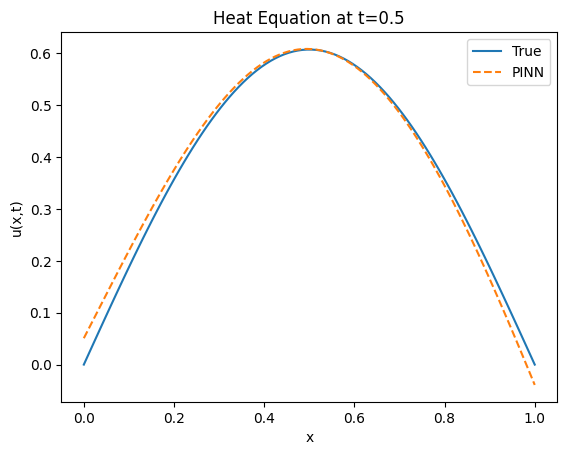

In [ ]:
# ----------------------------
# 7. Evaluation
# ----------------------------
u_pred = model(X_test).detach().numpy()             # Predict u(x,t) at the test grid points using the trained model and convert to numpy for plotting.

# True solution:        u(x,t) = sin(pi x) * exp(-alpha pi^2 t)
u_true = np.sin(np.pi * X.numpy()) * np.exp(-alpha * np.pi**2 * T.numpy())

# ----------------------------
# 8. Plot (slice at t=0.5)
# ----------------------------
t_index = 50

plt.plot(x_test.numpy(), u_true[:,t_index], label="True")
plt.plot(x_test.numpy(), u_pred.reshape(100,100)[:,t_index], '--', label="PINN")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Heat Equation at t=0.5")
plt.legend()
plt.show()